In [1]:
%load_ext watermark


In [2]:
import itertools as it
import os
import string

import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from phyloframe import _auxlib as pfa
from phyloframe import legacy as pfl
from pyfonts import load_google_font
import seaborn as sns
from teeplot import teeplot as tp

import pylib  # noqa: F401


/opt/hostedtoolcache/Python/3.11.14/x64/lib/python3.11/site-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-03-05T00:12:36.868895+00:00

Python implementation: CPython
Python version       : 3.11.14
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

pandas    : 2.2.3
teeplot   : 1.4.2
numpy     : 2.1.2
pylib     : 0.0.0
seaborn   : 0.13.2
matplotlib: 3.10.0
phyloframe: 0.1.0

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2026-03-04-phylometrics")
teeplot_subdir


'2026-03-04-phylometrics'

In [5]:
pfa.seed_random(1)


In [6]:
font = load_google_font("Merriweather", weight=300)
mpl.font_manager.fontManager.addfont(font.get_file())
plt.rcParams["font.family"] = font.get_name()


## Prep Data


In [7]:
df_pure = pfl.alifestd_join_roots(
    pylib.read_parquet_with_retry("https://osf.io/download/pfvsg/"),
)
df_pure


,id,dstream_data_id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,genomeFlavor,globalSeed,nCol,...,CEREBRASLIB_TRAITLOGGER_DSTREAM_ALGO_NAME,CEREBRASLIB_HSTRAT_T_DILATION,CEREBRASLIB_HSTRAT_DSTREAM_ALGO_NAME,ASYNC_GA_GENOME_FLAVOR,is_extant,layer,layer_T,position,is_root,is_oldest_root
0,0,9223372036854775807,0,0,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,True,True
1,1,9223372036854775807,0,510,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
2,2,9223372036854775807,1,1022,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
3,3,9223372036854775807,2,1534,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
4,4,9223372036854775807,3,3070,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99950,99950,999556085,99744,151216,1,64,bf7ffeba00024eb10a68ef4ccad354610049ce12,genome_purifyingonly,1.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingonly,False,1249.0,8761.0,439435.0,False,False
99951,99951,999555051,97585,151219,1,64,bf7ffeb400024eb40a68ef4cc40779dd0049ce67,genome_purifyingonly,1.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingonly,False,1249.0,8761.0,438401.0,False,False
99952,99952,999592311,99337,151222,1,64,bf7ffeb500024eb70a68af4c4cd76dc10049cec3,genome_purifyingonly,1.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingonly,False,1249.0,8761.0,475661.0,False,False
99953,99953,999522298,97024,151225,1,64,bf7ffeb400024eba0268ef4c5da3b9c90049cf24,genome_purifyingonly,1.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingonly,False,1249.0,8761.0,405648.0,False,False


In [8]:
df_sweep = pfl.alifestd_join_roots(
    pylib.read_parquet_with_retry("https://osf.io/download/nk69s/"),
)
df_sweep


,id,dstream_data_id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,genomeFlavor,globalSeed,nCol,...,CEREBRASLIB_TRAITLOGGER_DSTREAM_ALGO_NAME,CEREBRASLIB_HSTRAT_T_DILATION,CEREBRASLIB_HSTRAT_DSTREAM_ALGO_NAME,ASYNC_GA_GENOME_FLAVOR,is_extant,layer,layer_T,position,is_root,is_oldest_root
0,0,9223372036854775807,0,0,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,True,True
1,1,9223372036854775807,0,2046,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
2,2,9223372036854775807,1,15870,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
3,3,9223372036854775807,2,16287,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
4,4,9223372036854775807,3,16383,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99872,99872,999754987,99704,147913,1,64,c9477d70000241cadfb756bb95f5820600483125,genome_purifyingsweep,2.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingsweep,False,1249.0,9873.0,638337.0,False,False
99873,99873,999934079,99643,147915,1,64,c9478350000241ccdfb716bb34f586c60048316f,genome_purifyingsweep,2.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingsweep,False,1249.0,9873.0,817429.0,False,False
99874,99874,999989329,99507,147918,1,64,c9478cc0000241cfdfb756bb2bf18946004831c1,genome_purifyingsweep,2.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingsweep,False,1249.0,9873.0,872679.0,False,False
99875,99875,999919661,99699,147920,1,64,c9477d10000241d1dfb756bb26f594c60048320f,genome_purifyingsweep,2.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingsweep,False,1249.0,9873.0,803011.0,False,False


In [9]:
dfs = []
for df in (df_pure, df_sweep):
    df["x"] = df["position"] // df["nCol"]
    df["x_"] = df["x"] / df["nRow"]
    df["y"] = df["position"] % df["nCol"]
    df["y_"] = df["y"] / df["nCol"]

    df["origin_time"] = df["dstream_rank"]
    df = pfl.alifestd_mark_origin_time_delta_asexual(df, mutate=True)
    df["log_origin_time_delta"] = np.log10(df["origin_time_delta"] + 1)
    df["branch_length"] = df["origin_time_delta"]
    df["log_branch_length"] = df["log_origin_time_delta"]

    df = pfl.alifestd_mark_sackin_index_asexual(df, mutate=True)
    df = pfl.alifestd_mark_colless_like_index_mdm_asexual(df, mutate=True)
    df = pfl.alifestd_mark_leaves(df, mutate=True)
    df = pfl.alifestd_mark_roots(df, mutate=True)

    df["log_sackin_index"] = np.log10(df["sackin_index"] + 1)
    df["log_colless_like_index_mdm"] = np.log10(
        df["colless_like_index_mdm"] + 1
    )

    df["tree_richness"] = df["log_branch_length"]
    df["tree_depth"] = df["sackin_index"]
    df["tree_imbalance"] = df["colless_like_index_mdm"]

    dfs.append(df)

df_pure, df_sweep = dfs


## Helpers


In [10]:
def make_xlabel(raw: str) -> str:
    raw = raw.replace("colless_like", "Colless-like")
    raw = raw.removesuffix("_mdm")
    if raw.startswith("log_"):
        name = raw.removeprefix("log_")
        # raw = fr"$\log_{{10}}(\text{{{string.capwords(name.replace('_', ' '))}}})$"
        raw = rf"log₁₀({string.capwords(name.replace('_', ' '))})"
    else:
        raw = string.capwords(raw.replace("_", " "))
    return raw


## Plot Leaf Tree Stats


In [11]:
data = pd.concat(
    [
        df_pure[df_pure["is_leaf"]].assign(regime="purifying"),
        df_sweep[df_sweep["is_leaf"]].assign(regime="adaptive"),
    ],
    ignore_index=True,
)


teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=leaf+x=origin-time+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=leaf+x=origin-time+ext=.png


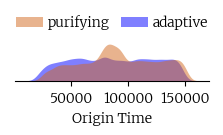

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=leaf+x=origin-time+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=leaf+x=origin-time+ext=.png


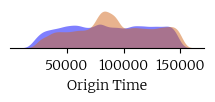

In [12]:
for x, legend in it.product(
    ("origin_time",),
    (True, False),
):
    with tp.teed(
        sns.kdeplot,
        data=data,
        x=x,
        hue="regime",
        hue_order=["purifying", "adaptive"],
        alpha=0.5,
        common_norm=False,
        fill=True,
        legend=legend,
        linewidth=0,
        palette=["chocolate", "blue"],
        teeplot_outattrs={"legend": legend, "what": "leaf"},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        if legend:
            sns.move_legend(
                teed,
                "lower center",
                bbox_to_anchor=(0.5, 1),
                columnspacing=0.8,
                frameon=False,
                handletextpad=0.3,
                ncol=3,
                title=None,
            )
        sns.despine(ax=teed, left=True)
        teed.set_yticks([])
        teed.figure.set_size_inches(2.5, 0.5)
        teed.set_xlabel(make_xlabel(x))
        teed.set_ylabel("")


teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=barplot+what=leaf+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=barplot+what=leaf+x=origin-time+y=regime+ext=.png


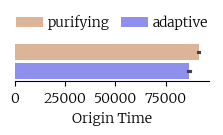

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=barplot+what=leaf+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=barplot+what=leaf+x=origin-time+y=regime+ext=.png


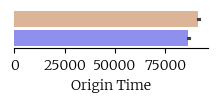

In [13]:
for x, legend in it.product(
    ("origin_time",),
    (True, False),
):
    with tp.teed(
        sns.barplot,
        data=data,
        x=x,
        y="regime",
        hue="regime",
        hue_order=["purifying", "adaptive"],
        alpha=0.5,
        legend=legend,
        palette=["chocolate", "blue"],
        teeplot_outattrs={"legend": legend, "what": "leaf"},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        if legend:
            sns.move_legend(
                teed,
                "lower center",
                bbox_to_anchor=(0.5, 1),
                columnspacing=0.8,
                frameon=False,
                handletextpad=0.3,
                ncol=3,
                title=None,
            )
        sns.despine(ax=teed, left=True)
        teed.set_yticks([])
        teed.figure.set_size_inches(2.5, 0.5)
        teed.set_xlabel(make_xlabel(x))
        teed.set_ylabel("")


## Plot whole-tree stats


In [14]:
data = pd.concat(
    [
        df_pure.assign(regime="purifying"),
        df_sweep.assign(regime="adaptive"),
    ],
    ignore_index=True,
)


teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=branch-length+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=branch-length+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


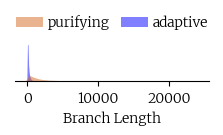

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=branch-length+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=branch-length+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


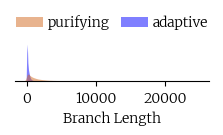

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=branch-length+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=branch-length+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


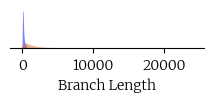

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=branch-length+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=branch-length+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


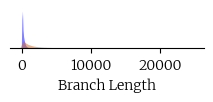

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=log-branch-length+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=log-branch-length+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


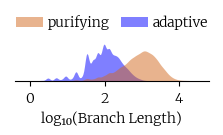

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=log-branch-length+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=log-branch-length+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


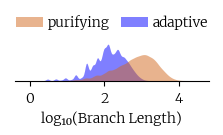

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=log-branch-length+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=log-branch-length+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


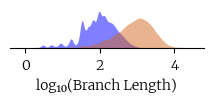

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=log-branch-length+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=log-branch-length+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


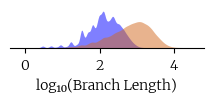

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=origin-time+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=origin-time+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


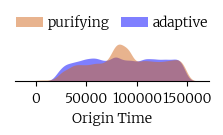

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=origin-time+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=origin-time+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


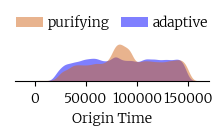

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=origin-time+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=origin-time+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


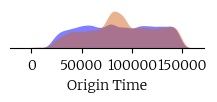

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=origin-time+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=origin-time+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


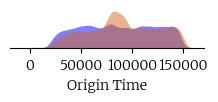

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=origin-time-delta+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=origin-time-delta+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


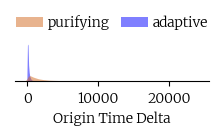

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=origin-time-delta+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=origin-time-delta+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


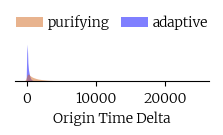

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=origin-time-delta+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=origin-time-delta+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


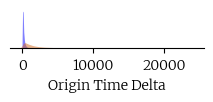

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=origin-time-delta+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=origin-time-delta+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


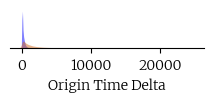

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=log-origin-time-delta+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=log-origin-time-delta+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


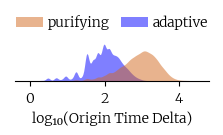

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=log-origin-time-delta+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=log-origin-time-delta+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


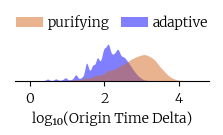

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=log-origin-time-delta+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=log-origin-time-delta+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


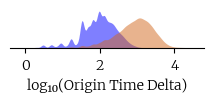

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=log-origin-time-delta+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=log-origin-time-delta+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


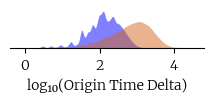

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=sackin-index+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=sackin-index+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


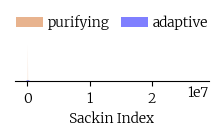

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=sackin-index+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=sackin-index+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


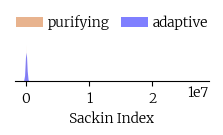

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=sackin-index+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=sackin-index+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


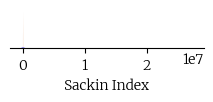

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=sackin-index+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=sackin-index+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


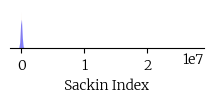

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=log-sackin-index+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=log-sackin-index+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


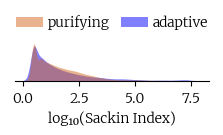

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=log-sackin-index+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=log-sackin-index+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


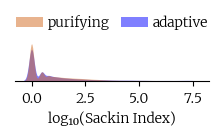

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=log-sackin-index+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=log-sackin-index+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


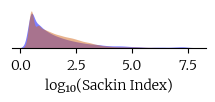

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=log-sackin-index+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=log-sackin-index+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


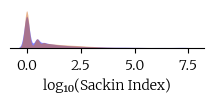

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=colless-like-index-mdm+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=colless-like-index-mdm+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


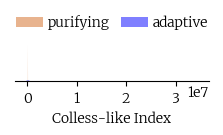

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=colless-like-index-mdm+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=colless-like-index-mdm+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


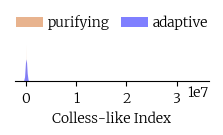

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=colless-like-index-mdm+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=colless-like-index-mdm+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


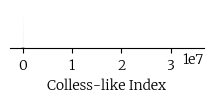

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=colless-like-index-mdm+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=colless-like-index-mdm+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


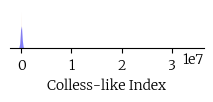

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=log-colless-like-index-mdm+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=log-colless-like-index-mdm+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


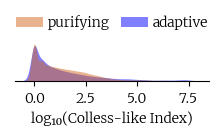

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=log-colless-like-index-mdm+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=log-colless-like-index-mdm+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


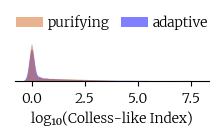

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=log-colless-like-index-mdm+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=log-colless-like-index-mdm+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


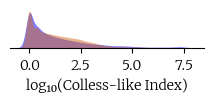

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=log-colless-like-index-mdm+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=log-colless-like-index-mdm+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


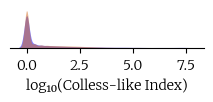

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=tree-depth+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=tree-depth+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


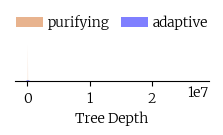

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=tree-depth+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=tree-depth+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


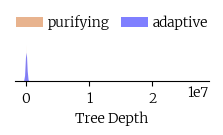

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=tree-depth+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=tree-depth+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


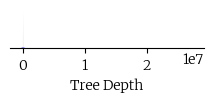

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=tree-depth+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=tree-depth+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


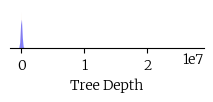

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=tree-imbalance+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=tree-imbalance+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


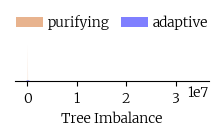

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=tree-imbalance+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=tree-imbalance+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


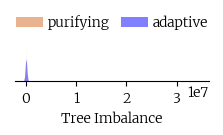

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=tree-imbalance+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=tree-imbalance+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


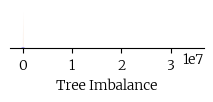

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=tree-imbalance+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=tree-imbalance+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


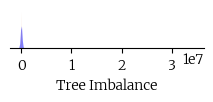

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=tree-richness+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=inner+x=tree-richness+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


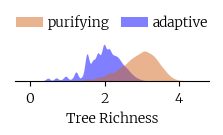

teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=tree-richness+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=True+viz=kdeplot+what=all+x=tree-richness+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


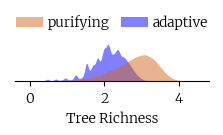

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=tree-richness+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=inner+x=tree-richness+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


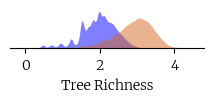

teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=tree-richness+ext=.pdf
teeplots/2026-03-04-phylometrics/hue=regime+legend=False+viz=kdeplot+what=all+x=tree-richness+ext=.png


/tmp/ipykernel_4984/1929483061.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


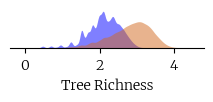

In [15]:
for x, legend, what in it.product(
    (
        "branch_length",
        "log_branch_length",
        "origin_time",
        "origin_time_delta",
        "log_origin_time_delta",
        "sackin_index",
        "log_sackin_index",
        "colless_like_index_mdm",
        "log_colless_like_index_mdm",
        "tree_depth",
        "tree_imbalance",
        "tree_richness",
    ),
    (True, False),
    ("inner", "all"),
):
    if what == "inner":
        data_ = data[~data["is_leaf"]]
    else:
        data_ = data

    with tp.teed(
        sns.kdeplot,
        data=data_,
        x=x,
        hue="regime",
        hue_order=["purifying", "adaptive"],
        alpha=0.5,
        common_norm=False,
        fill=True,
        legend=legend,
        linewidth=0,
        palette=["chocolate", "blue"],
        teeplot_outattrs={"legend": legend, "what": what},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        if legend:
            sns.move_legend(
                teed,
                "lower center",
                bbox_to_anchor=(0.5, 1),
                columnspacing=0.8,
                frameon=False,
                handletextpad=0.3,
                ncol=3,
                title=None,
            )
        sns.despine(ax=teed, left=True)
        teed.set_yticks([])
        teed.figure.set_size_inches(2.5, 0.5)
        teed.set_xlabel(make_xlabel(x))
        teed.set_ylabel("")
        teed.get_xaxis().get_offset_text().set_position((0.95, 0))
        teed.figure.tight_layout()
        teed.figure.draw_without_rendering()
        teed.text(
            1.0,
            -0.1,
            teed.get_xaxis().get_offset_text().get_text(),
            ha="right",
            va="top",
            transform=teed.transAxes,
        )
        teed.get_xaxis().get_offset_text().set_visible(False)


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


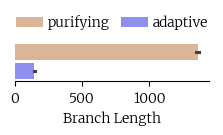

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


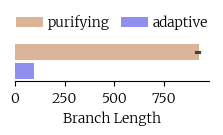

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


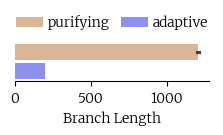

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


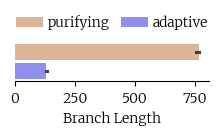

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=branch-length+y=regime+ext=.png


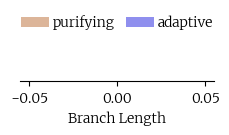

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=branch-length+y=regime+ext=.png


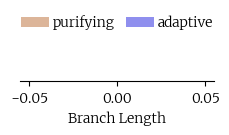

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


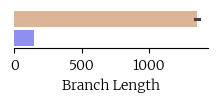

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


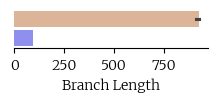

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


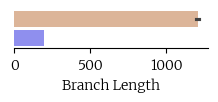

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


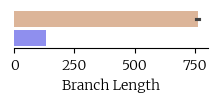

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=branch-length+y=regime+ext=.png


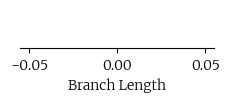

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=branch-length+y=regime+ext=.png


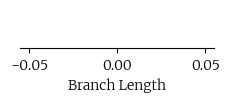

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=log-branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=log-branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


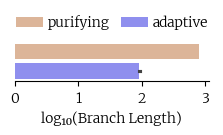

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=log-branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=log-branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


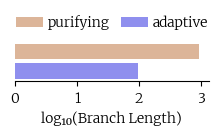

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=log-branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=log-branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


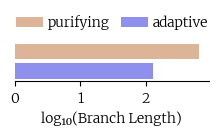

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=log-branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=log-branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


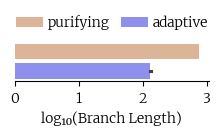

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=log-branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=log-branch-length+y=regime+ext=.png


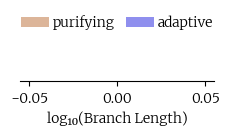

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=log-branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=log-branch-length+y=regime+ext=.png


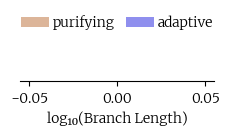

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=log-branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=log-branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


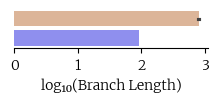

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=log-branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=log-branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


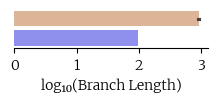

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=log-branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=log-branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


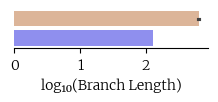

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=log-branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=log-branch-length+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


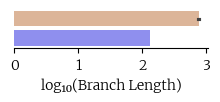

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=log-branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=log-branch-length+y=regime+ext=.png


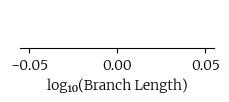

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=log-branch-length+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=log-branch-length+y=regime+ext=.png


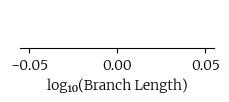

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=origin-time+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


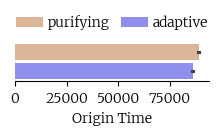

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=origin-time+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


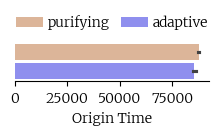

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=origin-time+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


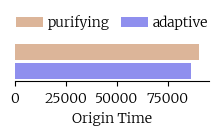

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=origin-time+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


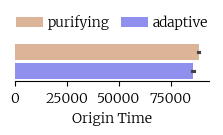

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=origin-time+y=regime+ext=.png


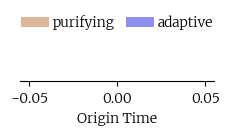

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=origin-time+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


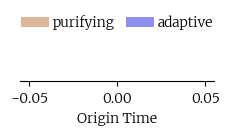

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=origin-time+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


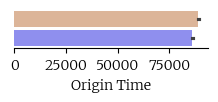

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=origin-time+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


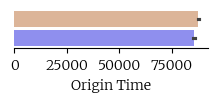

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=origin-time+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


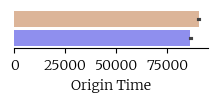

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=origin-time+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


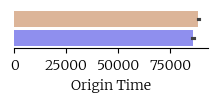

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=origin-time+y=regime+ext=.png


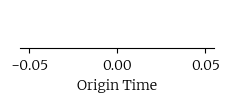

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=origin-time+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=origin-time+y=regime+ext=.png


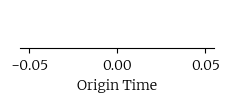

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


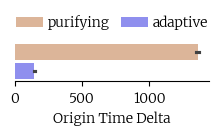

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


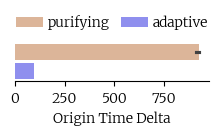

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


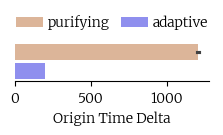

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


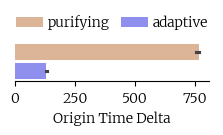

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=origin-time-delta+y=regime+ext=.png


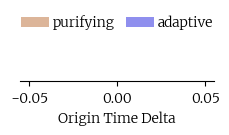

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=origin-time-delta+y=regime+ext=.png


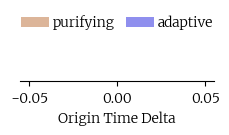

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


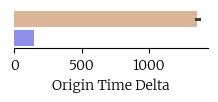

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


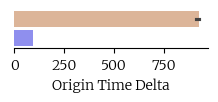

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


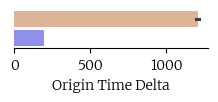

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


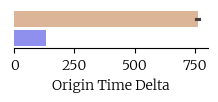

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=origin-time-delta+y=regime+ext=.png


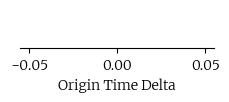

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=origin-time-delta+y=regime+ext=.png


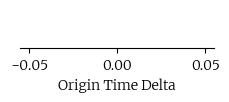

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=log-origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=log-origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


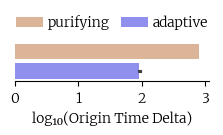

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=log-origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=log-origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


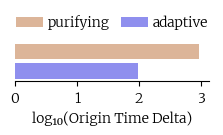

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=log-origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=log-origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


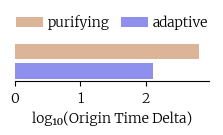

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=log-origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=log-origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


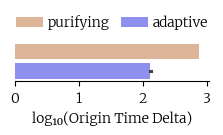

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=log-origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=log-origin-time-delta+y=regime+ext=.png


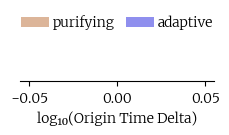

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=log-origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=log-origin-time-delta+y=regime+ext=.png


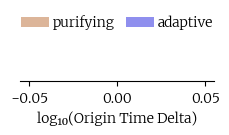

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=log-origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=log-origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


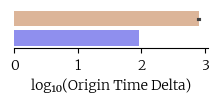

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=log-origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=log-origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


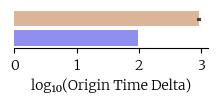

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=log-origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=log-origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


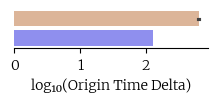

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=log-origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=log-origin-time-delta+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


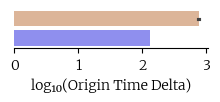

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=log-origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=log-origin-time-delta+y=regime+ext=.png


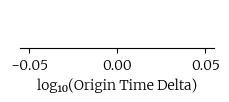

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=log-origin-time-delta+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=log-origin-time-delta+y=regime+ext=.png


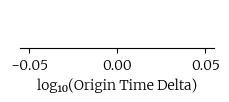

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


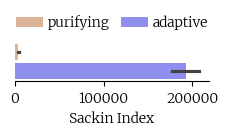

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


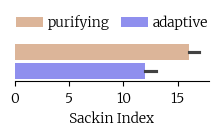

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


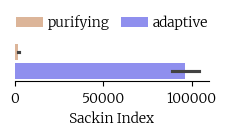

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


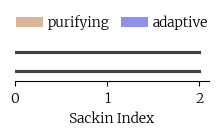

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=sackin-index+y=regime+ext=.png


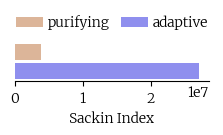

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


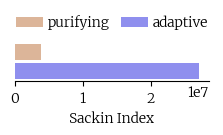

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


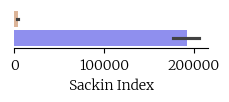

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


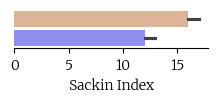

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


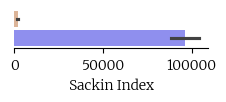

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


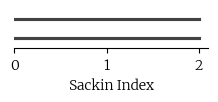

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=sackin-index+y=regime+ext=.png


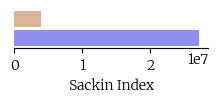

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=sackin-index+y=regime+ext=.png


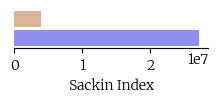

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=log-sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=log-sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


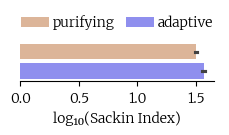

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=log-sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=log-sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


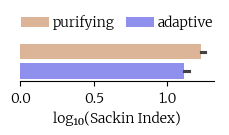

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=log-sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=log-sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


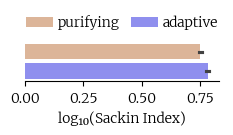

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=log-sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=log-sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


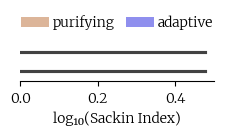

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=log-sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=log-sackin-index+y=regime+ext=.png


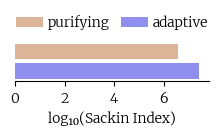

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=log-sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=log-sackin-index+y=regime+ext=.png


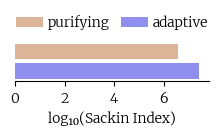

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=log-sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=log-sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


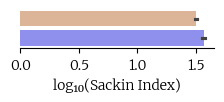

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=log-sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=log-sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


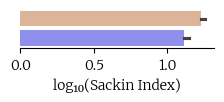

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=log-sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=log-sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


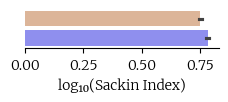

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=log-sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=log-sackin-index+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


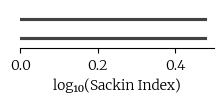

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=log-sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=log-sackin-index+y=regime+ext=.png


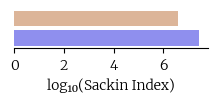

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=log-sackin-index+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=log-sackin-index+y=regime+ext=.png


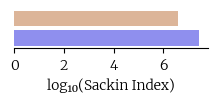

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


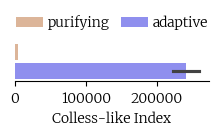

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


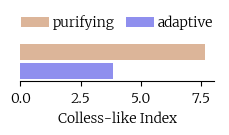

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


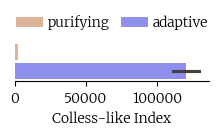

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


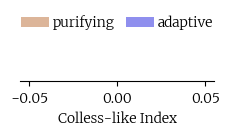

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=colless-like-index-mdm+y=regime+ext=.png


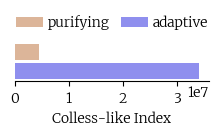

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=colless-like-index-mdm+y=regime+ext=.png


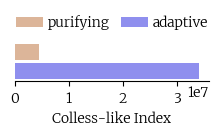

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


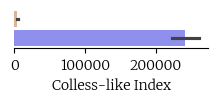

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


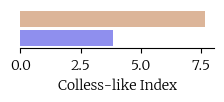

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


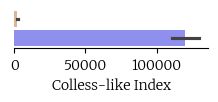

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


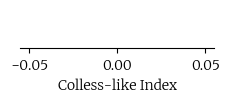

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=colless-like-index-mdm+y=regime+ext=.png


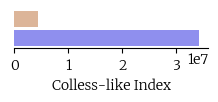

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=colless-like-index-mdm+y=regime+ext=.png


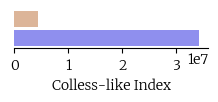

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=log-colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=log-colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


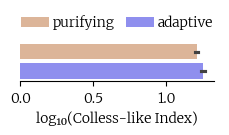

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=log-colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=log-colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


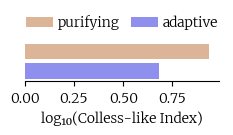

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=log-colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=log-colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


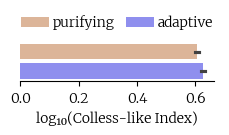

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=log-colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=log-colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


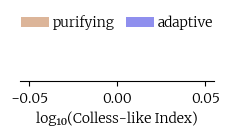

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=log-colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=log-colless-like-index-mdm+y=regime+ext=.png


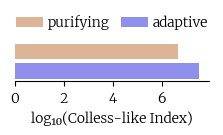

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=log-colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=log-colless-like-index-mdm+y=regime+ext=.png


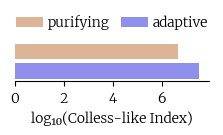

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=log-colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=log-colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


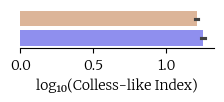

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=log-colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=log-colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


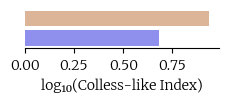

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=log-colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=log-colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


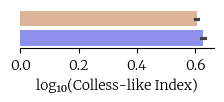

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=log-colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=log-colless-like-index-mdm+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


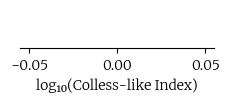

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=log-colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=log-colless-like-index-mdm+y=regime+ext=.png


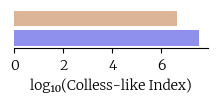

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=log-colless-like-index-mdm+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=log-colless-like-index-mdm+y=regime+ext=.png


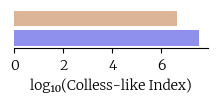

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=tree-depth+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=tree-depth+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


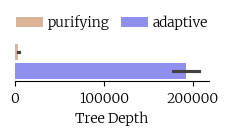

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=tree-depth+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=tree-depth+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


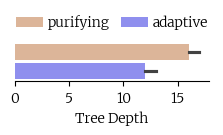

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=tree-depth+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=tree-depth+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


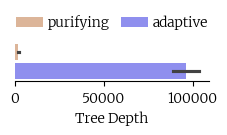

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=tree-depth+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=tree-depth+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


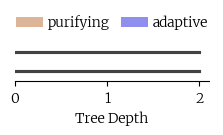

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=tree-depth+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=tree-depth+y=regime+ext=.png


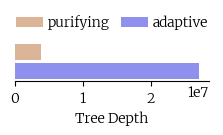

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=tree-depth+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=tree-depth+y=regime+ext=.png


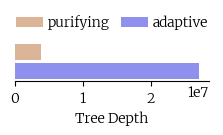

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=tree-depth+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=tree-depth+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


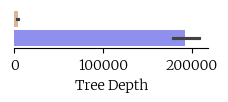

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=tree-depth+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=tree-depth+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


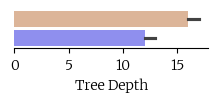

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=tree-depth+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=tree-depth+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


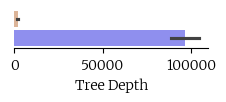

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=tree-depth+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=tree-depth+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


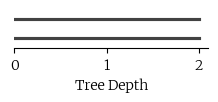

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=tree-depth+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=tree-depth+y=regime+ext=.png


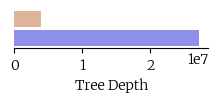

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=tree-depth+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=tree-depth+y=regime+ext=.png


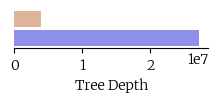

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=tree-imbalance+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=tree-imbalance+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


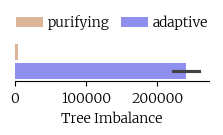

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=tree-imbalance+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=tree-imbalance+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


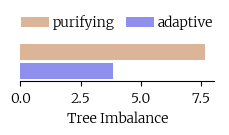

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=tree-imbalance+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=tree-imbalance+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


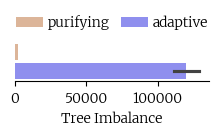

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=tree-imbalance+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=tree-imbalance+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


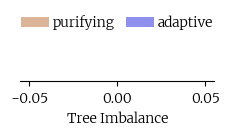

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=tree-imbalance+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=tree-imbalance+y=regime+ext=.png


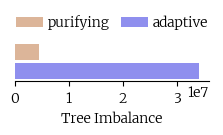

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=tree-imbalance+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=tree-imbalance+y=regime+ext=.png


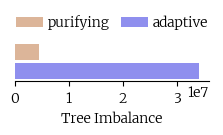

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=tree-imbalance+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=tree-imbalance+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


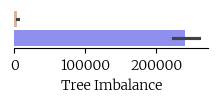

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=tree-imbalance+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=tree-imbalance+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


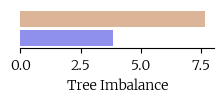

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=tree-imbalance+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=tree-imbalance+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


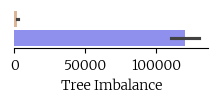

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=tree-imbalance+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=tree-imbalance+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


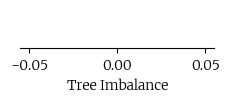

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=tree-imbalance+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=tree-imbalance+y=regime+ext=.png


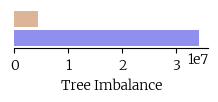

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=tree-imbalance+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=tree-imbalance+y=regime+ext=.png


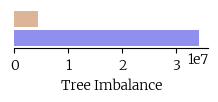

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=tree-richness+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=inner+x=tree-richness+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


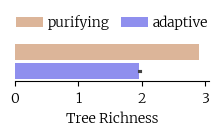

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=tree-richness+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=inner+x=tree-richness+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


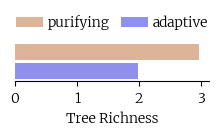

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=tree-richness+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=all+x=tree-richness+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


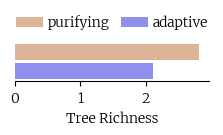

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=tree-richness+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=all+x=tree-richness+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


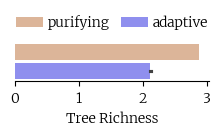

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=tree-richness+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=True+viz=barplot+what=root+x=tree-richness+y=regime+ext=.png


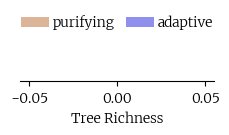

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=tree-richness+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=True+viz=barplot+what=root+x=tree-richness+y=regime+ext=.png


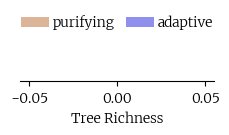

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=tree-richness+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=inner+x=tree-richness+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


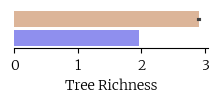

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=tree-richness+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=inner+x=tree-richness+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


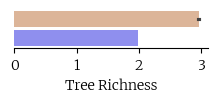

teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=tree-richness+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=all+x=tree-richness+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


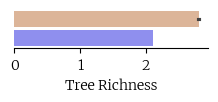

teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=tree-richness+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=all+x=tree-richness+y=regime+ext=.png


/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


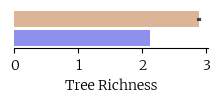

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=tree-richness+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=mean+hue=regime+legend=False+viz=barplot+what=root+x=tree-richness+y=regime+ext=.png


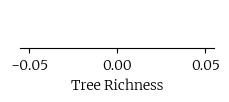

/tmp/ipykernel_4984/2009917225.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  teed.figure.tight_layout()


teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=tree-richness+y=regime+ext=.pdf
teeplots/2026-03-04-phylometrics/est=median+hue=regime+legend=False+viz=barplot+what=root+x=tree-richness+y=regime+ext=.png


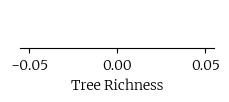

In [16]:
for x, legend, what, est in it.product(
    (
        "branch_length",
        "log_branch_length",
        "origin_time",
        "origin_time_delta",
        "log_origin_time_delta",
        "sackin_index",
        "log_sackin_index",
        "colless_like_index_mdm",
        "log_colless_like_index_mdm",
        "tree_depth",
        "tree_imbalance",
        "tree_richness",
    ),
    (True, False),
    ("inner", "all", "root"),
    (np.mean, np.median),
):

    if what == "inner":
        data_ = data[~data["is_leaf"]]
    elif what == "root":
        data_ = data[data["is_root"]]
    elif what == "all":
        data_ = data
    else:
        raise ValueError

    with tp.teed(
        sns.barplot,
        data=data_,
        x=x,
        y="regime",
        hue="regime",
        hue_order=["purifying", "adaptive"],
        alpha=0.5,
        estimator=est,
        legend=legend,
        palette=["chocolate", "blue"],
        teeplot_outattrs={"est": est.__name__, "legend": legend, "what": what},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        if legend:
            sns.move_legend(
                teed,
                "lower center",
                bbox_to_anchor=(0.5, 1),
                columnspacing=0.8,
                frameon=False,
                handletextpad=0.3,
                ncol=3,
                title=None,
            )
        sns.despine(ax=teed, left=True)
        teed.set_yticks([])
        teed.figure.set_size_inches(2.5, 0.5)
        teed.set_xlabel(make_xlabel(x))
        teed.set_ylabel("")
        teed.figure.tight_layout()
        teed.figure.draw_without_rendering()
        teed.text(
            1.0,
            -0.1,
            teed.get_xaxis().get_offset_text().get_text(),
            ha="right",
            va="top",
            transform=teed.transAxes,
        )
        teed.get_xaxis().get_offset_text().set_visible(False)
